### Reference
https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models

## Exploring Data

In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)

import gc
from datetime import datetime 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
from sklearn import svm
import lightgbm as lgb
from lightgbm import LGBMClassifier
import xgboost as xgb

pd.set_option('display.max_columns', 100)


RFC_METRIC = 'gini'  
NUM_ESTIMATORS = 100 #number of estimators used for RandomForrestClassifier
NO_JOBS = 4 #number of parallel jobs used for RandomForrestClassifier


#TRAIN/VALIDATION/TEST SPLIT
#VALIDATION
VALID_SIZE = 0.20 # simple validation using train_test_split
TEST_SIZE = 0.20 # test size using_train_test_split

#CROSS-VALIDATION
NUMBER_KFOLDS = 5 #number of KFolds for cross-validation

RANDOM_STATE = 2018
MAX_ROUNDS = 1000 #lgb iterations
EARLY_STOP = 50 #lgb early stop 
OPT_ROUNDS = 1000  #To be adjusted based on best validation rounds
VERBOSE_EVAL = 50 #Print out metric result

In [2]:
from pathlib import Path

PATH = Path("../../dados/raw_creditcard.csv")

data = pd.read_csv(PATH)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

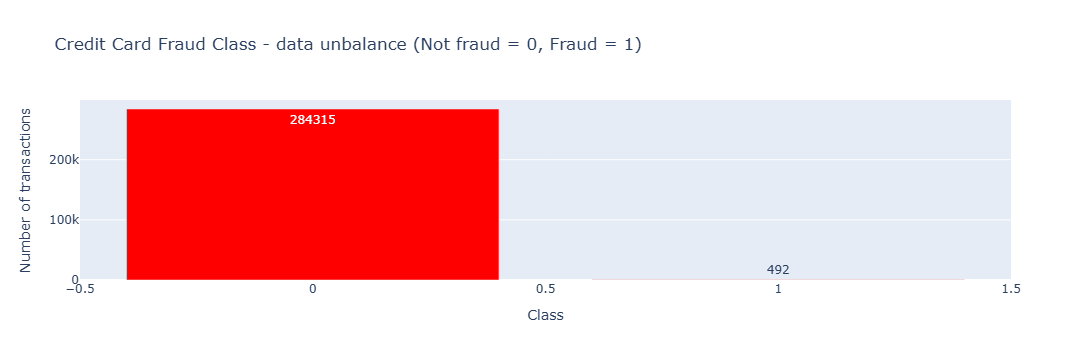

In [4]:
temp = data["Class"].value_counts()
df = pd.DataFrame({'Class': temp.index,'values': temp.values})

trace = go.Bar(
    x = df['Class'],y = df['values'],
    name="Credit Card Fraud Class - data unbalance (Not fraud = 0, Fraud = 1)",
    marker=dict(color="Red"),
    text=df['values']
)
data_plot = [trace]
layout = dict(title = 'Credit Card Fraud Class - data unbalance (Not fraud = 0, Fraud = 1)',
          xaxis = dict(title = 'Class', showticklabels=True), 
          yaxis = dict(title = 'Number of transactions'),
          hovermode = 'closest',width=600
         )
fig = dict(data=data_plot, layout=layout)
iplot(fig, filename='class')

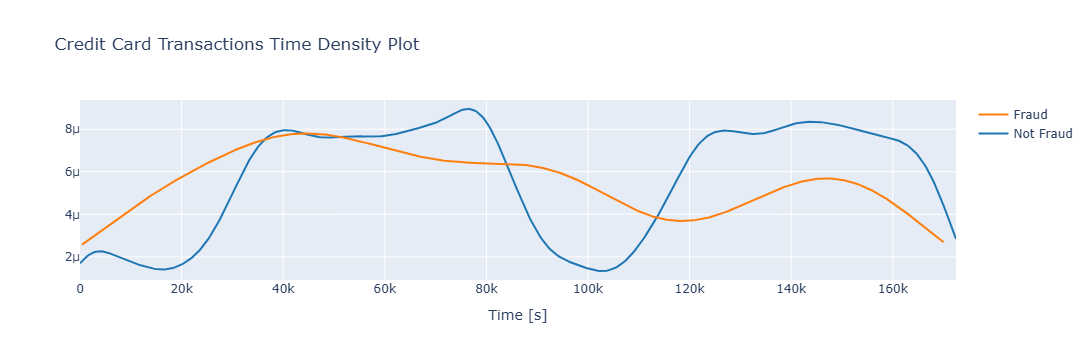

In [5]:
class_0 = data.loc[data['Class'] == 0]["Time"]
class_1 = data.loc[data['Class'] == 1]["Time"]

hist_data = [class_0, class_1]
group_labels = ['Not Fraud', 'Fraud']

fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False)
fig['layout'].update(title='Credit Card Transactions Time Density Plot', xaxis=dict(title='Time [s]'))
iplot(fig, filename='dist_only')

In [6]:
data['Hour'] = data['Time'].apply(lambda x: np.floor(x / 3600))

tmp = data.groupby(['Hour', 'Class'])['Amount'].aggregate(['min', 'max', 'count', 'sum', 'mean', 'median', 'var']).reset_index()
df = pd.DataFrame(tmp)
df.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']
df.head()

,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0.0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437


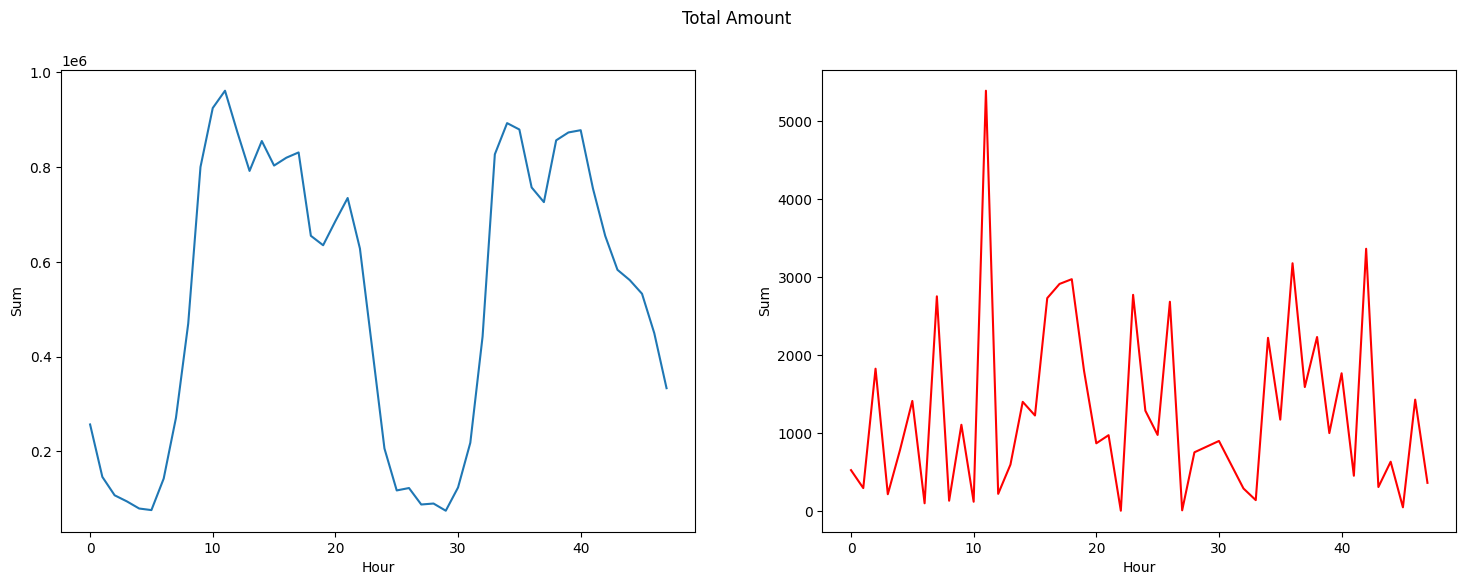

In [7]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Sum", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Sum", data=df.loc[df.Class==1], color="red")
plt.suptitle("Total Amount")
plt.show();

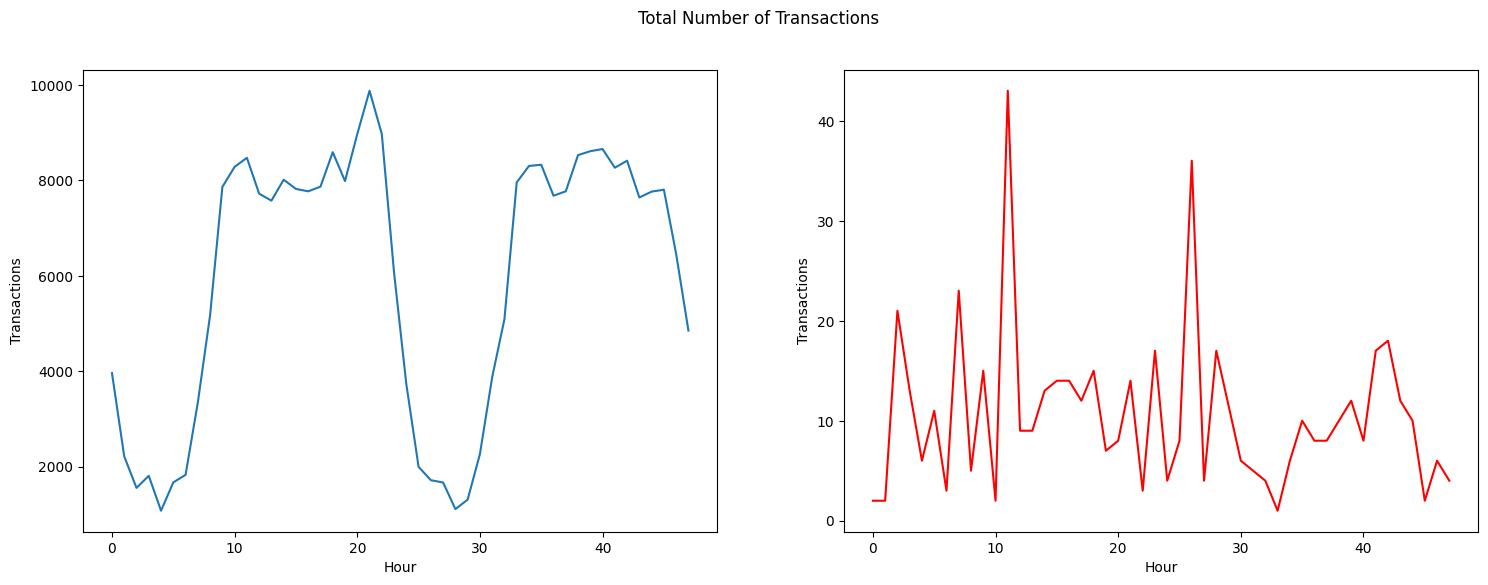

In [8]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Transactions", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Transactions", data=df.loc[df.Class==1], color="red")
plt.suptitle("Total Number of Transactions")
plt.show();

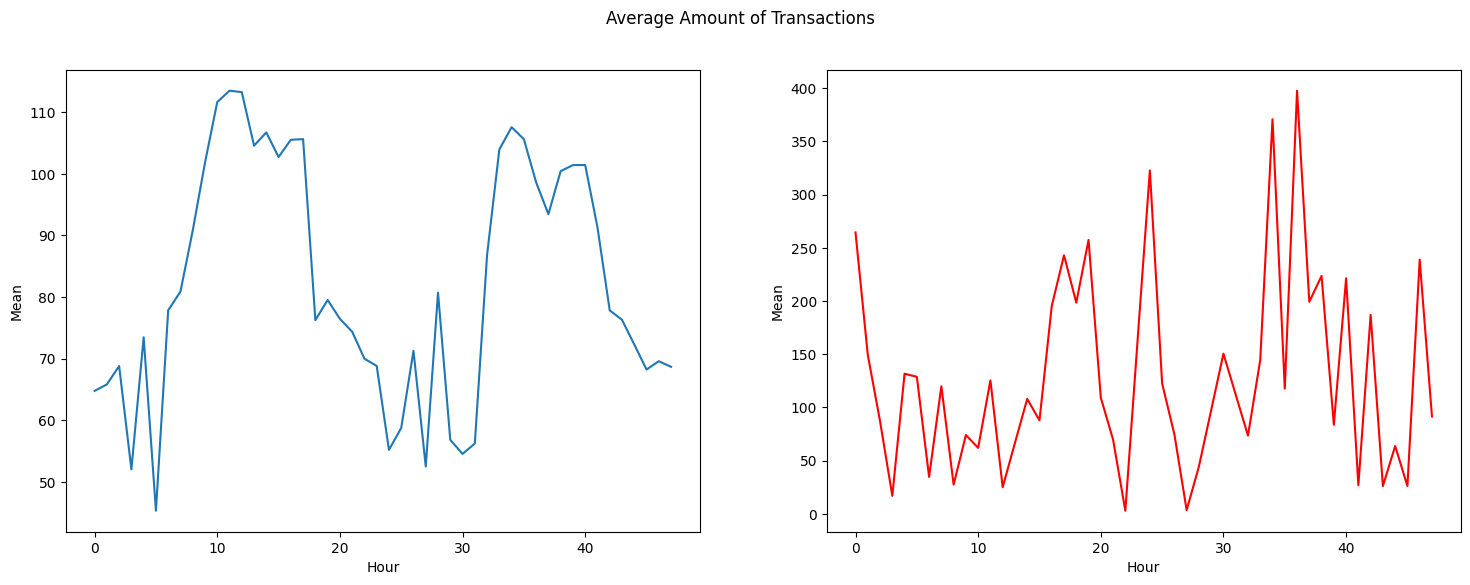

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Mean", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Mean", data=df.loc[df.Class==1], color="red")
plt.suptitle("Average Amount of Transactions")
plt.show();

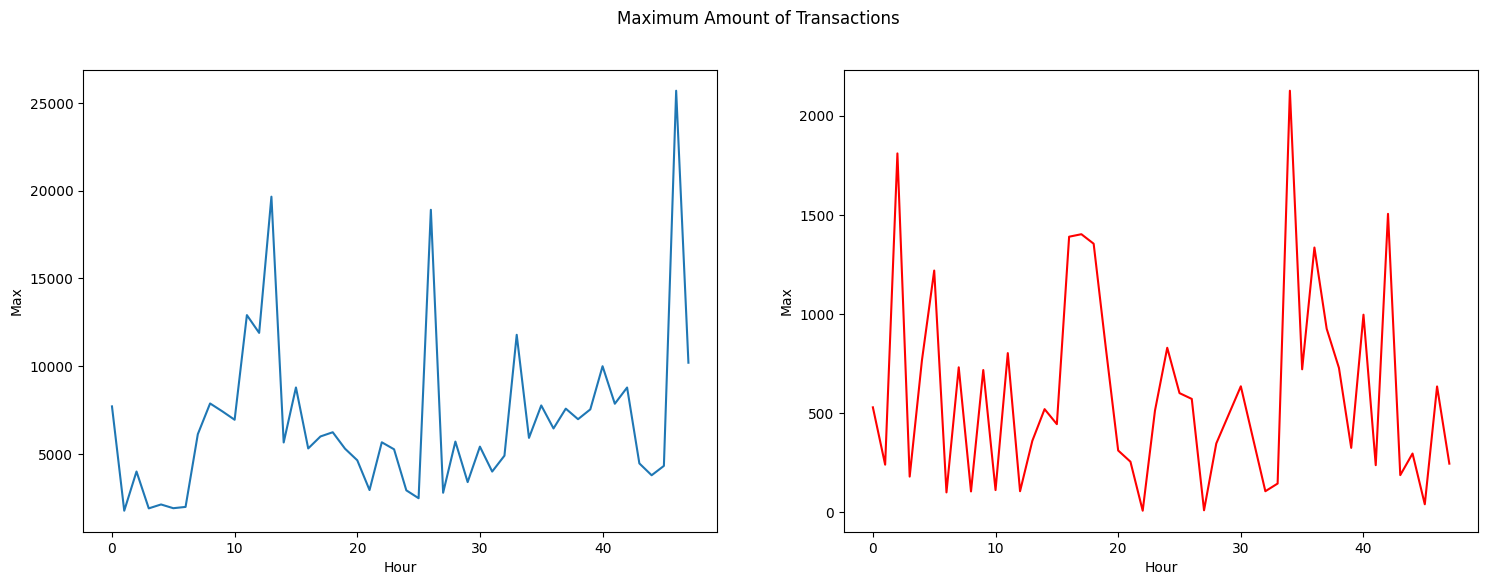

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hour", y="Max", data=df.loc[df.Class==0])
s = sns.lineplot(ax = ax2, x="Hour", y="Max", data=df.loc[df.Class==1], color="red")
plt.suptitle("Maximum Amount of Transactions")
plt.show();

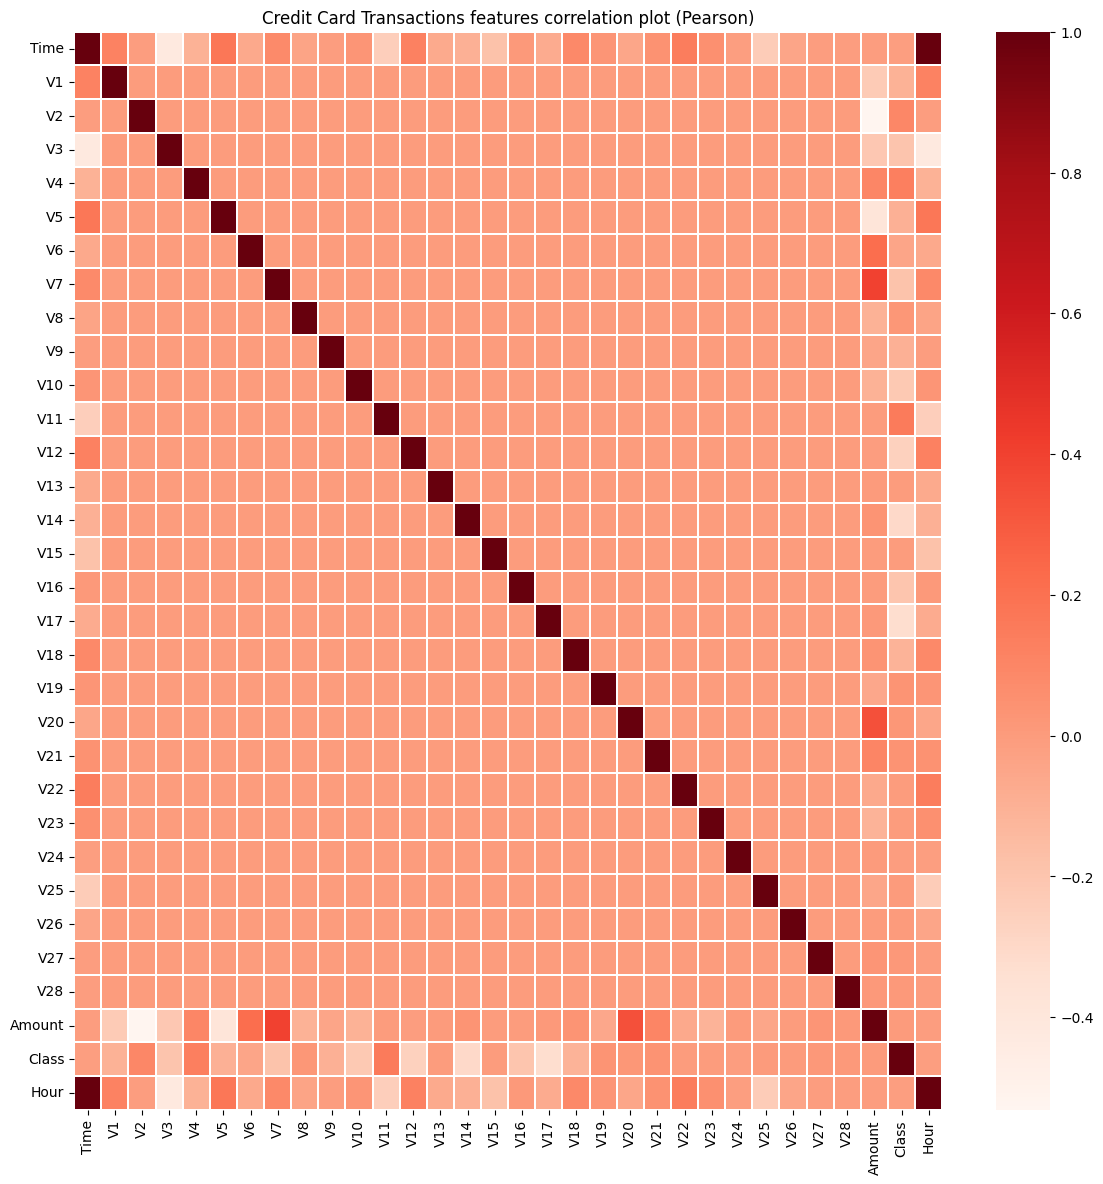

In [11]:
plt.figure(figsize = (14,14))
plt.title('Credit Card Transactions features correlation plot (Pearson)')
corr = data.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,linewidths=.1,cmap="Reds")
plt.show()

## Training

In [12]:
target = 'Class'
predictors = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',\
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',\
       'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',\
       'Amount']

In [13]:
train_df, test_df = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True )
train_df, valid_df = train_test_split(train_df, test_size=VALID_SIZE, random_state=RANDOM_STATE, shuffle=True )

In [14]:
# Prepare the train and valid datasets
dtrain = xgb.DMatrix(train_df[predictors], train_df[target].values)
dvalid = xgb.DMatrix(valid_df[predictors], valid_df[target].values)
dtest = xgb.DMatrix(test_df[predictors], test_df[target].values)

#What to monitor (in this case, **train** and **valid**)
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# Set xgboost parameters
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 2
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

In [15]:
model_0 = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:08:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	train-auc:0.93758	valid-auc:0.88823
[50]	train-auc:0.98237	valid-auc:0.97178
[100]	train-auc:0.99081	valid-auc:0.97822
[150]	train-auc:0.99381	valid-auc:0.97955
[189]	train-auc:0.99506	valid-auc:0.97905


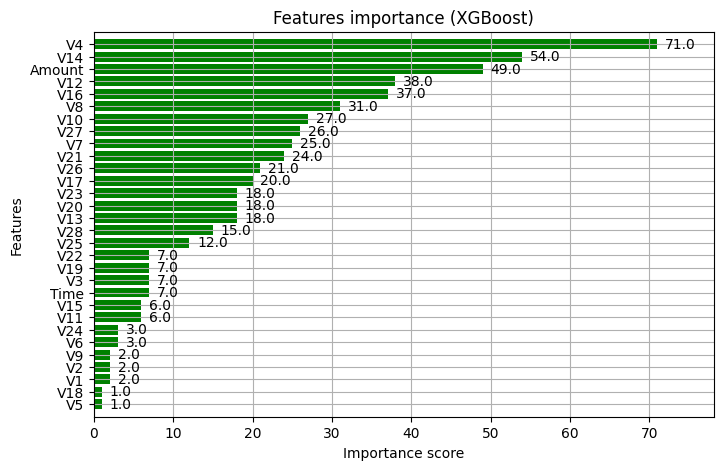

In [16]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model_0, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()

In [17]:
preds_0 = model_0.predict(dtest)

In [18]:
roc_auc_score(test_df[target].values, preds_0)

0.9769953571805423

In [19]:
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 2
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE
params['scale_pos_weight'] = 580

In [20]:
model_1 = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

[0]	train-auc:0.96131	valid-auc:0.95243


C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:09:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	train-auc:0.98882	valid-auc:0.98180
[100]	train-auc:0.99547	valid-auc:0.98595
[150]	train-auc:0.99809	valid-auc:0.98596
[200]	train-auc:0.99906	valid-auc:0.98537
[204]	train-auc:0.99911	valid-auc:0.98545


In [21]:
preds_1 = model_1.predict(dtest)

In [22]:
roc_auc_score(test_df[target].values, preds_1)

0.9690659843128978

In [23]:
MAX_ROUNDS = 5000 #lgb iterations

In [24]:
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.01
params['silent'] = True
params['max_depth'] = 6
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

In [25]:
model_2 = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

[0]	train-auc:0.97098	valid-auc:0.93068


C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:09:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	train-auc:0.98863	valid-auc:0.97009
[100]	train-auc:0.99301	valid-auc:0.97852
[150]	train-auc:0.99632	valid-auc:0.97847
[164]	train-auc:0.99703	valid-auc:0.97755


In [26]:
preds_2 = model_2.predict(dtest)
roc_auc_score(test_df[target].values, preds_2)

0.9656682846189019

### Feature Engineering

In [28]:
MAX_ROUNDS = 1000

In [29]:
mean_amount_train = train_df['Amount'].mean()

In [30]:
for df in [train_df, valid_df, test_df]:
    # 1. Log Amount
    df['log_amount'] = np.log1p(df['Amount'])
    
    # 2. Hour
    df['hour'] = (df['Time'] // 3600) % 24
    
    # 3. Diferença da média (usando o valor que extraímos do TREINO)
    df['diff_from_mean'] = df['Amount'] - mean_amount_train
    
    # 4. Interação (exemplo V4 e V14)
    df['v4_v14_inter'] = df['V4'] * df['V14']

In [31]:
predictors.append('log_amount')
predictors.append('hour')
predictors.append('diff_from_mean')
predictors.append('v4_v14_inter')

In [32]:
print(predictors)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'log_amount', 'hour', 'diff_from_mean', 'v4_v14_inter']


In [33]:
# Prepare the train and valid datasets
dtrain = xgb.DMatrix(train_df[predictors], train_df[target].values)
dvalid = xgb.DMatrix(valid_df[predictors], valid_df[target].values)
dtest = xgb.DMatrix(test_df[predictors], test_df[target].values)

#What to monitor (in this case, **train** and **valid**)
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# Set xgboost parameters
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 3
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

In [34]:
model_3 = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:09:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	train-auc:0.94692	valid-auc:0.88657
[50]	train-auc:0.98786	valid-auc:0.97456
[100]	train-auc:0.99606	valid-auc:0.97986
[150]	train-auc:0.99813	valid-auc:0.98249
[200]	train-auc:0.99910	valid-auc:0.98316
[250]	train-auc:0.99953	valid-auc:0.98324
[275]	train-auc:0.99967	valid-auc:0.98365


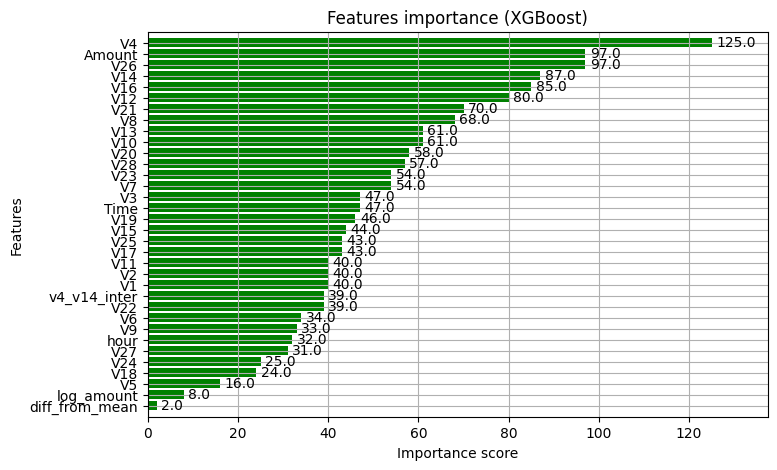

In [35]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model_3, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()

In [36]:
preds_3 = model_3.predict(dtest)
roc_auc_score(test_df[target].values, preds_3)

0.9815683584819388

In [37]:
# Set xgboost parameters
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 4
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

model_4 = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

[0]	train-auc:0.95356	valid-auc:0.90539


C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:09:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	train-auc:0.99243	valid-auc:0.97442
[100]	train-auc:0.99863	valid-auc:0.98009
[150]	train-auc:0.99962	valid-auc:0.98239
[200]	train-auc:0.99992	valid-auc:0.98171
[225]	train-auc:0.99997	valid-auc:0.98158


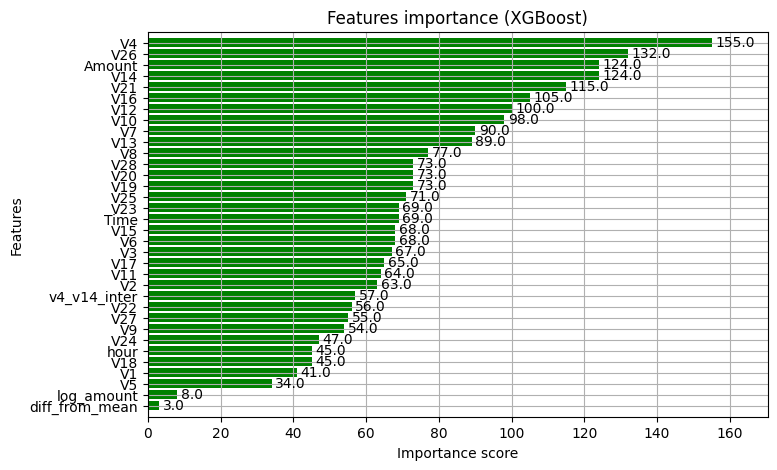

In [38]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model_4, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()

In [39]:
preds_4 = model_4.predict(dtest)
roc_auc_score(test_df[target].values, preds_4)

0.9801836024058247

In [40]:
params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 5
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = RANDOM_STATE

model_5 = xgb.train(params, 
                dtrain, 
                MAX_ROUNDS, 
                watchlist, 
                early_stopping_rounds=EARLY_STOP, 
                maximize=True, 
                verbose_eval=VERBOSE_EVAL)

[0]	train-auc:0.96319	valid-auc:0.91394


C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
C:\Repos\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [11:09:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	train-auc:0.99497	valid-auc:0.97471
[100]	train-auc:0.99955	valid-auc:0.97905
[150]	train-auc:0.99994	valid-auc:0.98246
[200]	train-auc:0.99999	valid-auc:0.98244
[224]	train-auc:1.00000	valid-auc:0.98119


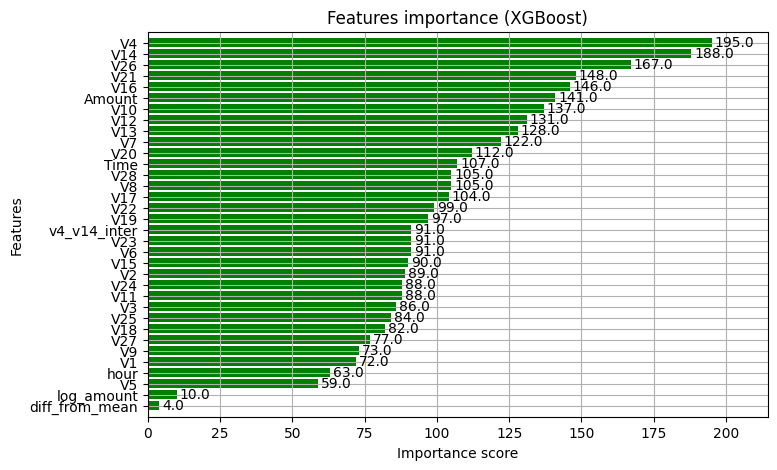

In [41]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model_5, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()

In [42]:
preds_5 = model_5.predict(dtest)
roc_auc_score(test_df[target].values, preds_5)

0.9717772853575322

## Evaluating the Best Model

In [43]:
best_model = model_3

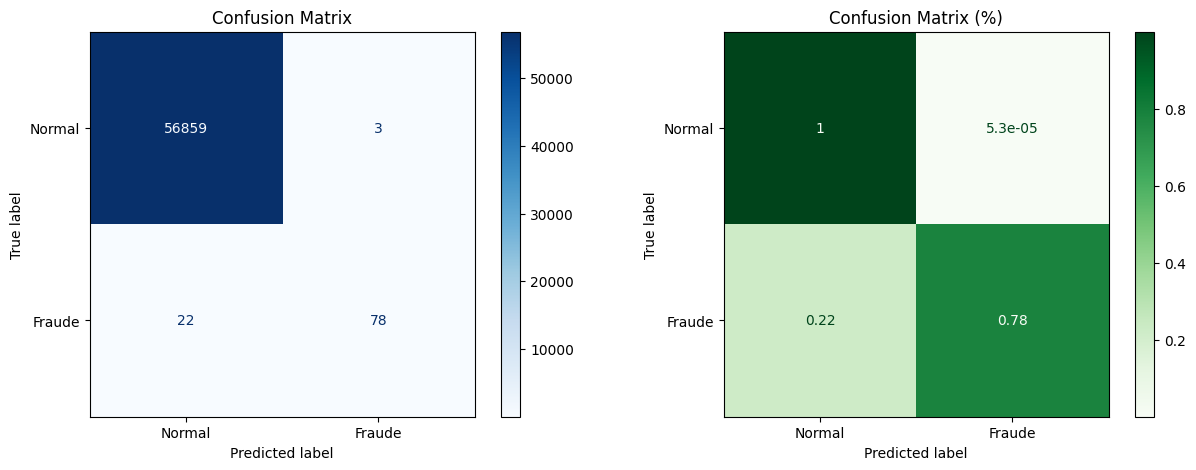

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds_prob = best_model.predict(dtest)

y_pred = (preds_prob > 0.5).astype(int)

y_true = test_df[target].values

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, 
    display_labels=['Normal', 'Fraude'], 
    cmap='Blues', ax=ax[0]
)
ax[0].set_title('Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, 
    display_labels=['Normal', 'Fraude'], 
    cmap='Greens', normalize='true', ax=ax[1]
)
ax[1].set_title('Confusion Matrix (%)')

plt.show()

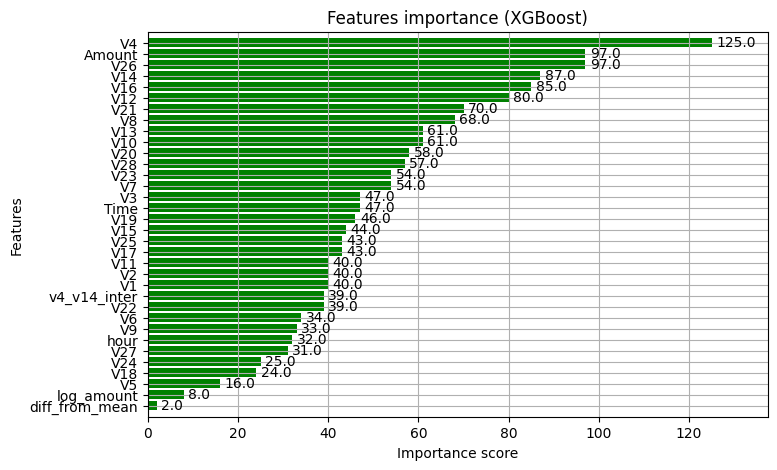

In [45]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(best_model, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()